In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("zomato.csv")

print(df.shape)
df.head()

(51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [16]:
# ----------------------------
# Create lightweight dataset (consistent with original df)
# ----------------------------

# Step 1: Copy original dataframe
sample_df = df.copy()

# Step 2: Drop heavy/unnecessary columns (if they exist)
cols_to_drop = [
    'reviews_list',
    'dish_liked',
    'phone',
    'url',
    'menu_item'
]

cols_to_drop = [col for col in cols_to_drop if col in sample_df.columns]
sample_df = sample_df.drop(columns=cols_to_drop)

# Step 3: Drop missing critical values
sample_df = sample_df.dropna(subset=['rate', 'approx_cost(for two people)'])


# Step 6: Save files
sample_df.to_csv("zomato_sample.csv", index=False)
sample_df.to_csv("zomato_sample.csv.gz", index=False, compression='gzip')

print("Sample dataset created successfully!")
print("Use zomato_sample.csv.gz for deployment")
df = sample_df

Sample dataset created successfully!
Use zomato_sample.csv.gz for deployment


In [17]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 30814 to 18489
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   address                      10000 non-null  str  
 1   name                         10000 non-null  str  
 2   online_order                 10000 non-null  str  
 3   book_table                   10000 non-null  str  
 4   rate                         10000 non-null  str  
 5   votes                        10000 non-null  int64
 6   location                     10000 non-null  str  
 7   rest_type                    9966 non-null   str  
 8   cuisines                     9996 non-null   str  
 9   approx_cost(for two people)  10000 non-null  str  
 10  listed_in(type)              10000 non-null  str  
 11  listed_in(city)              10000 non-null  str  
dtypes: int64(1), str(11)
memory usage: 2.6 MB


In [19]:
df = df[df['rate'].notna()]
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

df.shape

(9485, 12)

In [20]:
df['rate'] = df['rate'].apply(lambda x: float(x.split('/')[0]))

df['rate'].head()

30814    3.2
20819    3.0
16885    3.9
22394    3.7
4141     3.8
Name: rate, dtype: float64

In [21]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)                 # convert everything to string
    .str.replace(',', '')       # remove commas safely (vectorized)
    .replace('nan', np.nan)     # convert string 'nan' back to actual NaN
    .astype(float)              # convert to numeric
)

df['approx_cost(for two people)'].head()

30814    400.0
20819    550.0
16885    500.0
22394    200.0
4141     150.0
Name: approx_cost(for two people), dtype: float64

In [22]:
df = df[df['approx_cost(for two people)'].notna()]

df.shape

(9485, 12)

In [23]:
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})

df['online_order'].value_counts()

online_order
1    6257
0    3228
Name: count, dtype: int64

In [24]:
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})

df['book_table'].value_counts()

book_table
0    8094
1    1391
Name: count, dtype: int64

In [25]:
df['rest_type'] = df['rest_type'].fillna('Unknown')

df['rest_type'].unique()

<ArrowStringArray>
[                  'Quick Bites',                 'Casual Dining',
                'Dessert Parlor',            'Takeaway, Delivery',
           'Bakery, Quick Bites',                          'Cafe',
                        'Bakery',                    'Sweet Shop',
                      'Delivery',            'Bar, Casual Dining',
   'Microbrewery, Casual Dining',           'Cafe, Casual Dining',
            'Casual Dining, Bar',                   'Fine Dining',
       'Quick Bites, Sweet Shop',       'Sweet Shop, Quick Bites',
                    'Food Court',   'Quick Bites, Dessert Parlor',
                      'Takeaway',                         'Kiosk',
                 'Beverage Shop',          'Cafe, Dessert Parlor',
                           'Bar',            'Casual Dining, Pub',
    'Quick Bites, Beverage Shop',    'Beverage Shop, Quick Bites',
                          'Mess',                          'Club',
            'Pub, Casual Dining',          

In [26]:
df['cuisines'] = df['cuisines'].fillna('Unknown')

df['cuisines'].head()

30814                               South Indian
20819    North Indian, Biryani, Chinese, Seafood
16885                        Ice Cream, Desserts
22394                                    Biryani
4141                                    Lebanese
Name: cuisines, dtype: str

In [27]:
df['location'] = df['location'].fillna('Unknown')

df['location'].nunique()

90

In [28]:
df.drop_duplicates(inplace=True)

df.shape

(9483, 12)

In [29]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 9483 entries, 30814 to 18489
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      9483 non-null   str    
 1   name                         9483 non-null   str    
 2   online_order                 9483 non-null   int64  
 3   book_table                   9483 non-null   int64  
 4   rate                         9483 non-null   float64
 5   votes                        9483 non-null   int64  
 6   location                     9483 non-null   str    
 7   rest_type                    9483 non-null   str    
 8   cuisines                     9483 non-null   str    
 9   approx_cost(for two people)  9483 non-null   float64
 10  listed_in(type)              9483 non-null   str    
 11  listed_in(city)              9483 non-null   str    
dtypes: float64(2), int64(3), str(7)
memory usage: 2.3 MB


,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
30814,"694, Swagath Main Road, Tilak Nagar, 4th Block...",Sk Grand Hotel,0,0,3.2,6,Jayanagar,Quick Bites,South Indian,400.0,Delivery,Koramangala 5th Block
20819,"No 173, Munivenkatappa Layout, Bilekahalli, Op...",Sakshi,1,0,3.0,38,Bannerghatta Road,Casual Dining,"North Indian, Biryani, Chinese, Seafood",550.0,Delivery,Jayanagar
16885,"1702, 19th Main Road, Sector 2, HSR, Bangalore",Cream Chemistry,1,0,3.9,75,HSR,Dessert Parlor,"Ice Cream, Desserts",500.0,Desserts,HSR
22394,"644, 1 B, Main Road, Kanakapura Road, 8th Bloc...",Anand Donne Biriyani,1,0,3.7,46,Jayanagar,Quick Bites,Biryani,200.0,Delivery,JP Nagar
4141,"Behind Prestige Tech Park, Kadubisanahalli, Ma...",Absolute Shawarma,1,0,3.8,116,Marathahalli,"Takeaway, Delivery",Lebanese,150.0,Delivery,Bellandur


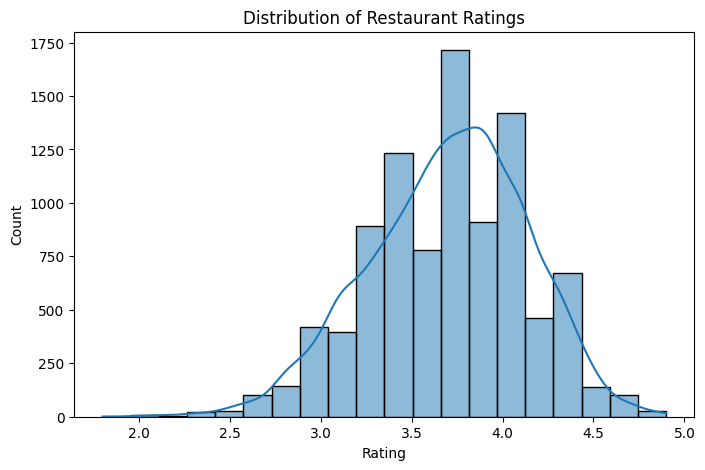

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['rate'], bins=20, kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [31]:
df['rate'].describe()

count    9483.000000
mean        3.701540
std         0.437785
min         1.800000
25%         3.400000
50%         3.700000
75%         4.000000
max         4.900000
Name: rate, dtype: float64

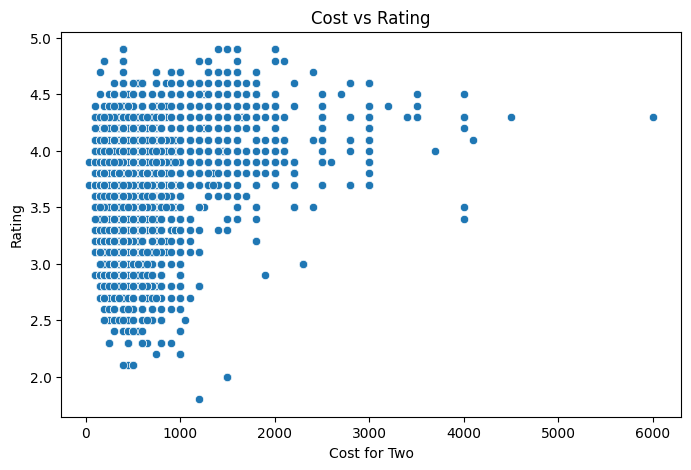

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['approx_cost(for two people)'], y=df['rate'])

plt.title("Cost vs Rating")
plt.xlabel("Cost for Two")
plt.ylabel("Rating")

plt.show()

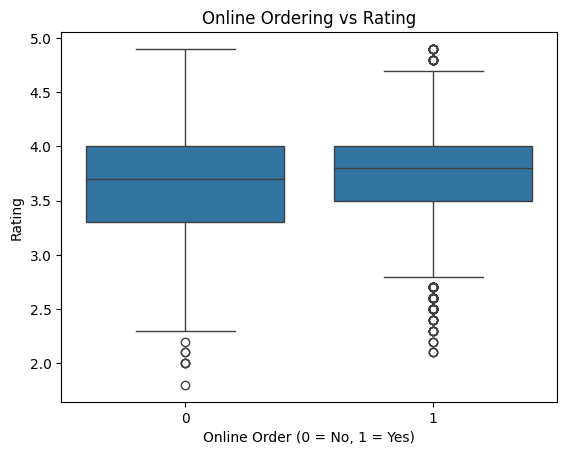

In [33]:
sns.boxplot(x='online_order', y='rate', data=df)

plt.title("Online Ordering vs Rating")
plt.xlabel("Online Order (0 = No, 1 = Yes)")
plt.ylabel("Rating")

plt.show()

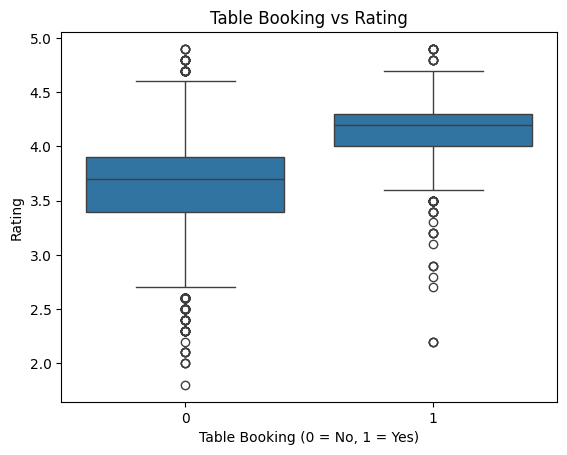

In [34]:
sns.boxplot(x='book_table', y='rate', data=df)

plt.title("Table Booking vs Rating")
plt.xlabel("Table Booking (0 = No, 1 = Yes)")
plt.ylabel("Rating")

plt.show()

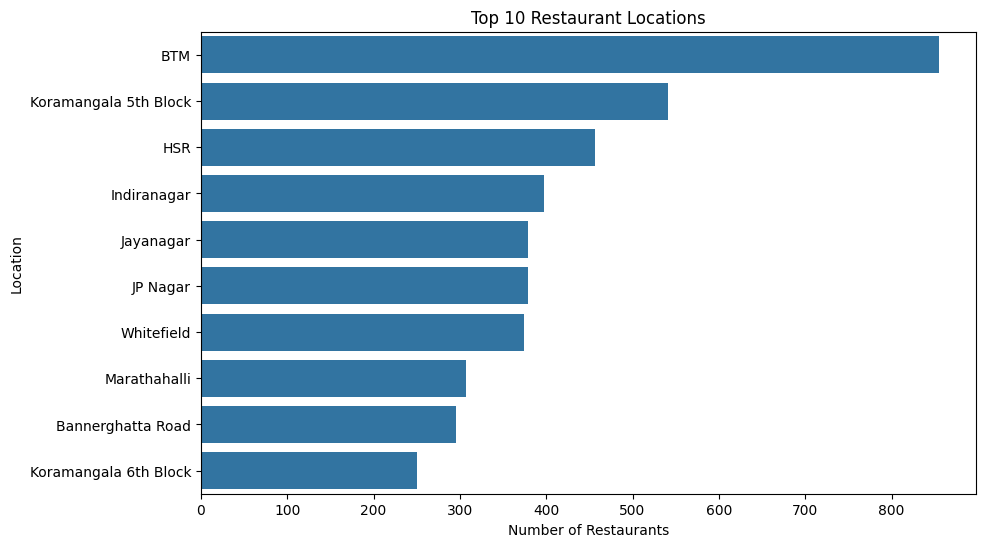

In [35]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.show()

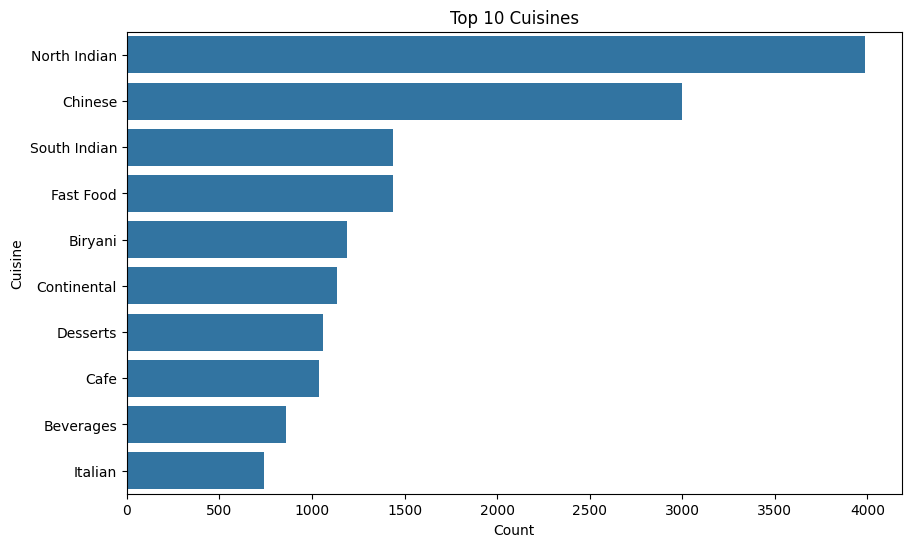

In [36]:
cuisines_series = df['cuisines'].str.split(', ').explode()
top_cuisines = cuisines_series.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.title("Top 10 Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")

plt.show()

In [37]:
print("Average Rating:", round(df['rate'].mean(), 2))
print("Median Rating:", df['rate'].median())
print("Min Rating:", df['rate'].min())
print("Max Rating:", df['rate'].max())

Average Rating: 3.7
Median Rating: 3.7
Min Rating: 1.8
Max Rating: 4.9


In [38]:
correlation = df['approx_cost(for two people)'].corr(df['rate'])
print("Correlation between Cost and Rating:", round(correlation, 3))

Correlation between Cost and Rating: 0.368


In [39]:
df.groupby('online_order')['rate'].mean()

online_order
0    3.655700
1    3.725196
Name: rate, dtype: float64

In [40]:
df.groupby('book_table')['rate'].mean()

book_table
0    3.625704
1    4.142703
Name: rate, dtype: float64

In [41]:
# ----------------------------
# Quantified Online Ordering Impact
# ----------------------------

group1 = df[df['online_order'] == 1]['rate']
group0 = df[df['online_order'] == 0]['rate']

mean_online = group1.mean()
mean_offline = group0.mean()
diff = mean_online - mean_offline
percent = (diff / mean_offline) * 100 if mean_offline != 0 else 0

print(f"Mean Rating (Online): {mean_online:.2f}")
print(f"Mean Rating (Offline): {mean_offline:.2f}")
print(f"Difference: {diff:.2f}")
print(f"Percentage Impact: {percent:.2f}%")

Mean Rating (Online): 3.73
Mean Rating (Offline): 3.66
Difference: 0.07
Percentage Impact: 1.90%


In [42]:
# ----------------------------
# Hypothesis Test (Online vs Offline)
# ----------------------------

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(group1, group0)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")

if p_val < 0.05:
    print("Result: Statistically significant difference in ratings.")
else:
    print("Result: No statistically significant difference.")

T-statistic: 7.3454
P-value: 0.000000
Result: Statistically significant difference in ratings.


In [43]:
df.to_csv("zomato_cleaned.csv.gz", index=False)